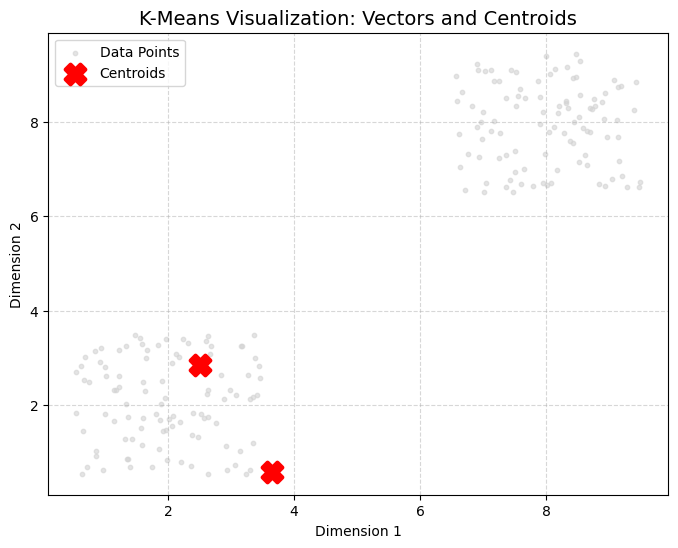

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
# iloc is used to handle files with or without headers
vectors = pd.read_csv("vectors.csv")
centroids = pd.read_csv("centroids0.csv")

# 2. Create the plot
plt.figure(figsize=(8, 6))

# Plot the raw vectors in light gray
plt.scatter(vectors.iloc[:, 0], vectors.iloc[:, 1], 
            c='lightgray', s=10, alpha=0.6, label='Data Points')

# Plot the centroids as large red 'X' markers
plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1], 
            c='red', marker='X', s=200, linewidths=3, label='Centroids')

# Formatting
plt.title("K-Means Visualization: Vectors and Centroids", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Show or Save
plt.show()
# plt.savefig("kmeans_result.png", dpi=300)

Generating GIF... please wait.
Done! Open 'kmeans_animation.gif' to see the result.


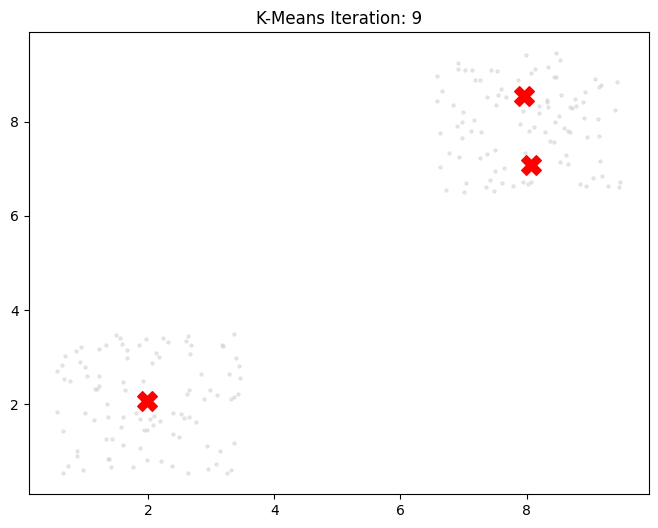

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import os

# 1. Configuration
num_iterations = 10
vector_file = "vectors.csv"

# Check if files exist before starting
if not os.path.exists(vector_file):
    raise FileNotFoundError(f"Could not find {vector_file}")

vectors = pd.read_csv(vector_file)

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(8, 6))
# Plot background points once
ax.scatter(vectors.iloc[:, 0], vectors.iloc[:, 1], c='lightgray', s=5, alpha=0.5)
scat = ax.scatter([], [], c='red', marker='X', s=200)
title = ax.set_title("K-Means Iteration: 0")

def update(frame):
    filename = f"centroids{frame}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        # Update the positions of the red X's
        scat.set_offsets(df.values)
        title.set_text(f"K-Means Iteration: {frame}")
    return scat, title

# 3. Create and Save
ani = FuncAnimation(fig, update, frames=range(num_iterations), blit=True)

print("Generating GIF... please wait.")
# Note: You may need to 'pip install pillow' if you haven't yet
ani.save('kmeans_animation.gif', writer='pillow', fps=2)
print("Done! Open 'kmeans_animation.gif' to see the result.")

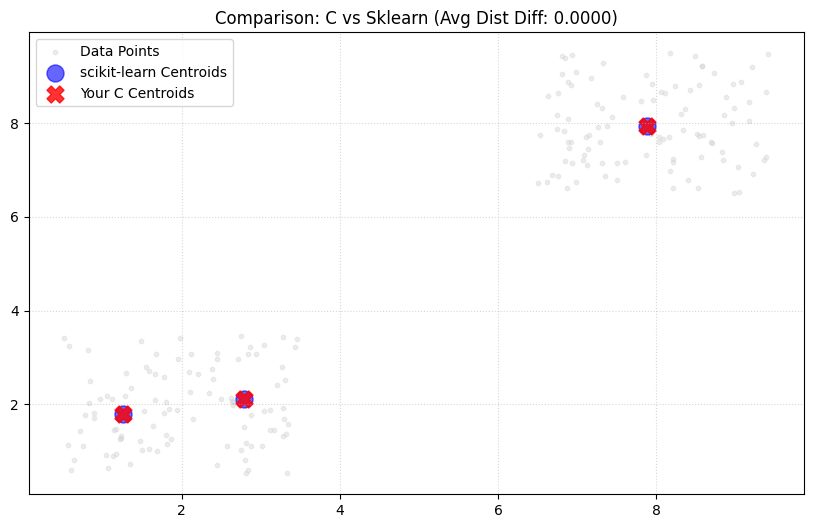

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

# 1. Load Data
vectors = pd.read_csv("vectors.csv") # Ensure headers match your CSV
k = 3 # Change this to your n_centroids

# 2. Run scikit-learn's KMeans
# Using 'random' init and n_init=1 to be more comparable to a basic C implementation
sk_kmeans = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300)
sk_kmeans.fit(vectors)
sk_centroids = sk_kmeans.cluster_centers_

# 3. Load your final iteration
your_final_file = "centroids9.csv"
if os.path.exists(your_final_file):
    your_centroids = pd.read_csv(your_final_file).values
else:
    your_centroids = None
    print("Warning: centroids9.csv not found!")

# 4. Visualization
plt.figure(figsize=(10, 6))

# Background points
plt.scatter(vectors.iloc[:, 0], vectors.iloc[:, 1], c='lightgray', s=10, alpha=0.4, label='Data Points')

# Plot Sklearn results (Blue circles)
plt.scatter(sk_centroids[:, 0], sk_centroids[:, 1], 
            c='blue', marker='o', s=150, alpha=0.6, label='scikit-learn Centroids')

# Plot Your results (Red X's)
if your_centroids is not None:
    plt.scatter(your_centroids[:, 0], your_centroids[:, 1], 
                c='red', marker='X', s=150, alpha=0.8, label='Your C Centroids')

# Comparison Metrics
if your_centroids is not None:
    # Note: Centroids might be in a different order, so we find the closest matches
    from scipy.spatial.distance import cdist
    distances = cdist(sk_centroids, your_centroids).min(axis=1)
    avg_diff = distances.mean()
    plt.title(f"Comparison: C vs Sklearn (Avg Dist Diff: {avg_diff:.4f})")
else:
    plt.title("Comparison: C vs Sklearn")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()